In [1]:
import math
import warnings
from itertools import chain
from functools import partial
from typing import Tuple, Any, Dict

from matplotlib import pyplot as plt

import jax
from jax import numpy as jnp
from jaxtyping import Array

from blueprint.systems import Transmon

In [2]:
def get_figsize(
    columns: int = 1,
    fig_width: float | None = None,
    fig_height: float | None = None,
    width_scale: float = 1.0,
    height_scale: float = 1.0,
) -> Tuple[float, float]:
    """
    get_figsize Returns the figure size for a matplotlib plot that is
    consistent with the IEEE journal template.

    Parameters
    ----------
    columns : int, optional
        The number of text columns that the figure takes up, by default 1
    fig_width : float | None, optional
        The width of the figure in inches, by default None
    fig_height : float | None, optional
        The height of the figure in inches, by default None
    width_scale : float, optional
        A scale factor for the width of the figure, by default 1.0
    height_scale : float, optional
        A scale factor for the height of the figure, by default 1.0

    Returns
    -------
    Tuple[float, float]
        The width and height of the figure in inches.

    Raises
    ------
    ValueError
        If the number of columns is not 1 or 2.
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    max_height = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = 3.4 if columns == 1 else 7
    # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > max_height:
        warnings.warn(
            f"Figure height {fig_height} is too large, setting to {max_height}"
            "inches instead"
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    """
    get_rc_params Returns the matplotlib rcParams for a plot that is consistent with the IEEE journal template.

    Parameters
    ----------
    **kwargs : Any
        Additional keyword arguments to pass to the rcParams. These will override the default values.
        The arguments that have pre-defined values are:
        - "axes.labelsize": 8
        - "axes.titlesize": 8
        - "legend.fontsize": 8
        - "xtick.labelsize": 8
        - "ytick.labelsize": 8
        - "text.usetex": False
        - "font.family": "serif"

    Returns
    -------
    Dict[str, Any]
        The dictionary of rcParams for the plot.
    """
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps", # Commented out because of backened issues
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,  # This should ideally be True, but leads to issues in certain cases.
        "font.family": "serif",
    }
    params.update(kwargs)
    return params


In [3]:
USE_DOUBLE_PRECISION: bool = True
USE_GPU: bool = False
DEVICE_IND: int = 0

if USE_DOUBLE_PRECISION:
    jax.config.update("jax_enable_x64", True)  # Double precision

if USE_GPU:
    cuda_devices = jax.devices("cuda")
    if not cuda_devices:
        raise ValueError("No GPU devices found.")

    device = cuda_devices[DEVICE_IND]
    jax.config.update("jax_default_device", device)

In [4]:
# units
GHZ = 2 * math.pi
MHZ = 2 * 1e-3 * math.pi

In [5]:
QUBIT_LABEL: str = "transmon"
CHARGING_ENERGY: float = 220 * MHZ
ENERGY_RATIO: float = 110
JOSEPHSON_ENERGY: float = ENERGY_RATIO * CHARGING_ENERGY
CHARGE_CUTOFF: int = 500
TRANSMON_DIM: int = 30

In [6]:
static_argnames=("label", "charge_cutoff", "dim")
@partial(jax.jit, static_argnames=static_argnames)
def get_transmon_energies(
    label: str,
    charging_energy: Array,
    josephson_energy: Array,
    offset_charge: Array,
    charge_cutoff: int,
    dim: int,
) -> Array:
    """
    get_transmon_energies Returns the energy levels of a transmon qubit given the offset charge.
    Parameters
    ----------
    offset_charge : float
        The offset charge of the transmon qubit.
    Returns
    -------
    Array
        The energy levels of the transmon qubit.
    """
    transmon = Transmon(
        label=label,
        charging_energy=charging_energy,
        josephson_energy=josephson_energy,
        offset_charge=offset_charge,
        charge_cutoff=charge_cutoff,
        dim=dim,
    )
    energies = transmon.get_eigenvalues()
    return energies

In [7]:
MIN_OFFSET_CHARGE: float = -2.0
MAX_OFFSET_CHARGE: float = 2.0
NUM_CHARGES: int = 100

offset_charges = jnp.linspace(MIN_OFFSET_CHARGE, MAX_OFFSET_CHARGE, NUM_CHARGES)

In [8]:
in_axes = (None, None, None, 0, None, None)
get_batched_energies = jax.vmap(get_transmon_energies, in_axes=in_axes)

In [9]:
energy_ratios = jnp.array([1.0, 5.0, 10.0, 50.0])


def scan_function(energy_ratio: Array) -> Array:
    josephson_energy = energy_ratio * CHARGING_ENERGY
    energies = get_batched_energies(
        QUBIT_LABEL,
        CHARGING_ENERGY,
        josephson_energy,
        offset_charges,
        CHARGE_CUTOFF,
        TRANSMON_DIM,
    )
    return energies


energies = jax.lax.map(scan_function, energy_ratios)

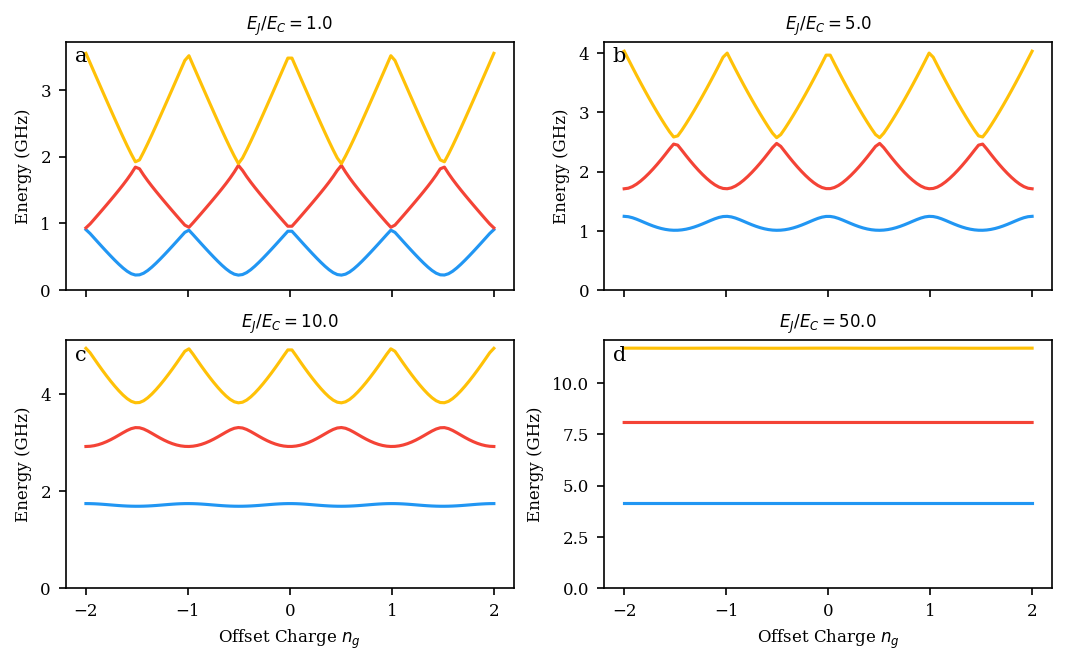

In [10]:
figsize = get_figsize(columns=2)
rc_params = get_rc_params()

mosaic = [["a", "b"], ["c", "d"]]
state_inds = [1, 2, 3]
colors = ["#2196f3", "#f44336", "#ffc107"]

subplot_labels = list(chain.from_iterable(mosaic))

xticks = jnp.array([-2, -1, 0, 1, 2])

with plt.rc_context(rc_params):
    fig, axes = plt.subplot_mosaic(  # type: ignore
        mosaic, # type: ignore
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
        dpi=150,
    )

    for energy_ind, subplot_label in enumerate(subplot_labels):
        axis = axes[subplot_label]
        energy_ratio = energy_ratios[energy_ind]

        for state_ind, color in zip(state_inds, colors):
            state_energies = energies[energy_ind, :, state_ind]
            label = f"State {state_ind}"
            axis.plot(
                offset_charges,
                state_energies / GHZ,
                color=color,
            )

        axis.set_title(f"$E_J/E_C = {energy_ratio:.1f}$")

        axis.set_ylabel("Energy (GHz)")
        axis.set_ylim(0, None)

        axis.text(0.02, 0.92, subplot_label, transform=axis.transAxes)

    for subplot_label in ("c", "d"):
        axis = axes[subplot_label]
        axis.set_xticks(xticks)
        axis.set_xlabel("Offset Charge $n_g$")
plt.show()